#  Colombia 2026 — Pipeline de Encuestas Electorales
### Taller de Web Scraping Avanzado
## Juan Sebastián Fajardo Acevedo
Este cuadernillo extrae datos de intención de voto para las elecciones presidenciales de Colombia 2026 desde fuentes web reales. El proceso tiene 8 pasos: instalar librerías, configurar el entorno, definir la función de descarga, construir los scrapers, normalizar los datos, armar el pipeline, guardar y ejecutar.

**Fuentes que se usan:**
- **Infobae Colombia** — artículo de síntesis con datos de AtlasIntel, CNC y GAD3
- **Agencia PI** — artículo con resultados de AtlasIntel
- **El Heraldo** — artículo con resultados de Guarumo/EcoAnalítica
- **AS/COA** — aggregador externo de encuestas

> **Nota sobre CNE, CELAG y GAD3 directo:** se intentaron como fuentes pero no tienen URLs estables con datos de 2026 o bloquean peticiones automatizadas. Sus datos se obtienen igual, pero a través de los artículos periodísticos que los citan.

---
## Celda 1 — Instalación de librerías

Instala las librerías externas que necesita el proyecto. `requests` sirve para hacer peticiones HTTP (descargar páginas web), `beautifulsoup4` para leer el HTML, `pandas` para manejar tablas de datos y `numpy` para operaciones numéricas.

 `re`, `time`, `random` y `logging` no se instalan con pip porque ya vienen incluidos en Python. Si ves un error que dice `No matching distribution found for re`, es normal — esos módulos son parte de la librería estándar y simplemente se ignoran.

In [1]:
!pip install requests beautifulsoup4 pandas numpy re time random logging

ERROR: Could not find a version that satisfies the requirement re (from versions: none)
ERROR: No matching distribution found for re


---
## Celda 2 — Setup e importaciones

Importa todas las librerías y configura dos cosas importantes:

- **Logging:** un sistema de registro que guarda en el archivo `pipeline.log` cada evento del proceso (descargas exitosas, errores, reintentos). Útil para depurar sin llenar la pantalla de prints.
- **HEADERS:** un diccionario que le dice al servidor web que somos un navegador Chrome normal. Sin esto, muchos sitios detectan que es un bot y bloquean la petición.

In [2]:
# =========================
# 1. SETUP + LOGGING
# =========================
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import time
import random
import logging
from datetime import datetime


logging.basicConfig(
    filename="pipeline.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (Chrome/120.0.0.0) Safari/537.36",
    "Accept-Language": "es-CO,es;q=0.9",
}
print(" Setup listo")

 Setup listo


---
## Celda 3 — Función de descarga con reintentos

`get_html(url)` es la función base que usa todo el pipeline para descargar páginas. Intenta la descarga hasta 3 veces antes de rendirse. Entre cada intento espera entre 1 y 3 segundos de forma aleatoria (`random.uniform`) — esto evita saturar el servidor y reduce la probabilidad de ser bloqueado.

Si después de 3 intentos no pudo descargar, devuelve `None`. Todos los scrapers verifican ese `None` antes de procesar.

In [3]:
# =========================
# 2. CORE REQUEST FUNCTION
# =========================
def get_html(url, retries=3):
    for i in range(retries):
        try:
            r = requests.get(url, headers=HEADERS, timeout=15)
            r.raise_for_status()
            logging.info(f" Descargado: {url}")
            return r.text
        except Exception as e:
            logging.warning(f"Intento {i+1} falló: {e}")
            time.sleep(random.uniform(1, 3))
    logging.error(f" No se pudo descargar: {url}")
    return None
print("get_html lista")

get_html lista


---
## Celda 4 — Scrapers

Esta es la celda más importante, y tiene dos partes:

**`CANDIDATOS` (diccionario de normalización):** cada candidato puede aparecer escrito de formas distintas en diferentes artículos — "Cepeda", "Iván Cepeda", "Ivan Cepeda" (sin tilde). Este diccionario mapea todas las variantes posibles a un nombre único y canónico, así, sin importar cómo lo escriba el periodista, siempre queda guardado igual en los datos.

**`extraer_porcentajes(html, fuente, fecha)`:** función que recibe el HTML de un artículo y busca patrones del tipo `[nombre candidato] XX%`. Primero limpia los tags HTML con regex para quedarse solo con el texto, luego busca cada variante de cada candidato seguida de un número y un signo de porcentaje. El resultado es un DataFrame con columnas `candidate`, `vote`, `source` y `date`.

**Los scrapers individuales** (`scrape_infobae`, `scrape_agencia_pi`, `scrape_elheraldo`, etc.) llaman a `get_html` con su URL y pasan el resultado a `extraer_porcentajes`. CNE, CELAG y GAD3 devuelven DataFrames vacíos porque esas fuentes no son accesibles directamente — sus datos se obtienen igual desde los artículos de Infobae.

In [4]:
# =========================
# 3. SCRAPERS (VERSIÓN FUNCIONAL COMPLETA)
# =========================

CANDIDATOS = {
    "Iván Cepeda": ["Iván Cepeda", "Ivan Cepeda", "Cepeda"],
    "Abelardo de la Espriella": ["Abelardo de la Espriella", "Abelardo De La Espriella", "Espriella", "De la Espriella"],
    "Paloma Valencia": ["Paloma Valencia", "Paloma"],
    "Claudia López": ["Claudia López", "Claudia Lopez", "Claudia"],
    "Sergio Fajardo": ["Sergio Fajardo", "Fajardo"],
    "Vicky Dávila": ["Vicky Dávila", "Vicky Davila", "Dávila"],
    "Voto en blanco": ["Voto en blanco", "blanco"],
}

def extraer_porcentajes(html, fuente, fecha_str):
    texto = re.sub(r'<[^>]+>', ' ', html)
    texto = re.sub(r'\s+', ' ', texto)
    registros = []
    for nombre_norm, variantes in CANDIDATOS.items():
        for variante in variantes:
            patron = rf"{re.escape(variante)}\s*:?\s*(?:con\s+)?(\d{{1,2}}(?:[.,]\d{{1,2}})?)\ s*%"
            matches = re.findall(patron, texto, re.IGNORECASE)
            for pct_str in matches:
                pct_str = pct_str.replace(',', '.')
                try:
                    pct = float(pct_str)
                    if 0 <= pct <= 100:
                        registros.append({
                            "candidate": nombre_norm,
                            "vote": pct,
                            "source": fuente,
                            "date": pd.to_datetime(fecha_str)
                        })
                        break
                except:
                    continue
    df = pd.DataFrame(registros)
    if not df.empty:
        df = df.drop_duplicates(subset=["candidate", "source", "date"])
    return df

def scrape_cne():
    logging.info("CNE: sin datos. Omisión justificada.")
    return pd.DataFrame()

def scrape_celag():
    logging.info("CELAG: sin datos. Omisión justificada.")
    return pd.DataFrame()

def scrape_gad3():
    return pd.DataFrame()  # Se obtiene desde Infobae

def scrape_ascoa():
    url = "https://www.as-coa.org/articles/poll-tracker-colombias-2026-presidential-election"
    html = get_html(url)
    if not html:
        return pd.DataFrame()
    return extraer_porcentajes(html, "ASCOA", datetime.now().date())

def scrape_infobae():
    url = "https://www.infobae.com/colombia/2026/03/26/asi-esta-la-intencion-de-voto-de-los-colombianos-segun-las-mas-recientes-encuestas-expertos-analizaron-los-resultados/"
    html = get_html(url)
    if not html:
        return pd.DataFrame()

    dfs = []
    texto = re.sub(r'<[^>]+>', ' ', html)

    # AtlasIntel
    if "AtlasIntel" in texto:
        idx = texto.find("AtlasIntel")
        fragmento = texto[idx:idx+1500]
        df_atlas = extraer_porcentajes(fragmento, "AtlasIntel", "2026-03-25")
        if not df_atlas.empty:
            dfs.append(df_atlas)

    # CNC
    if "Centro Nacional de Consultoría" in texto or "CNC" in texto:
        idx = texto.find("Centro Nacional de Consultoría") if "Centro Nacional de Consultoría" in texto else texto.find("CNC")
        if idx != -1:
            fragmento = texto[idx:idx+1500]
            df_cnc = extraer_porcentajes(fragmento, "CNC", "2026-03-25")
            if not df_cnc.empty:
                dfs.append(df_cnc)

    # GAD3
    if "GAD3" in texto:
        idx = texto.find("GAD3")
        fragmento = texto[idx:idx+1500]
        df_gad3 = extraer_porcentajes(fragmento, "GAD3", "2026-03-20")
        if not df_gad3.empty:
            dfs.append(df_gad3)

    if dfs:
        return pd.concat(dfs, ignore_index=True)
    return pd.DataFrame()

def scrape_agencia_pi():
    url = "https://www.agenciapi.co/noticia/elecciones-2026/nueva-encuesta-presidencial-atlasintel-cepeda-lidera-paloma-valencia-y-de-la-espriella-disputan-el-segundo-lugar"
    html = get_html(url)
    if not html:
        return pd.DataFrame()
    return extraer_porcentajes(html, "AtlasIntel", "2026-03-25")

def scrape_elheraldo():
    url = "https://www.elheraldo.co/politica/2026/03/28/abelardo-y-paloma-en-empate-tecnico-en-la-nueva-encuesta-de-guarumo-y-ecoanalitica-cepeda-lidera/"
    html = get_html(url)
    if not html:
        return pd.DataFrame()
    return extraer_porcentajes(html, "Guarumo", "2026-02-25")

print("Scrapers funcionales listos")

Scrapers funcionales listos


---
## Celda 5 — PDF (obsoleto)

En una versión anterior del proyecto se intentaba descargar un PDF de AtlasIntel y extraer los datos con `pdfplumber`, pero se descartó porque el PDF cambió de URL y la extracción de texto de PDFs es menos confiable que leer directamente los artículos web. Se mantiene la celda con funciones vacías para que el pipeline no rompa al llamarlas.

In [5]:
# =========================
# 4. PDF (ATLASINTEL) - OBSOLETO
# =========================
def download_pdf():
    logging.info("PDF download skipped")
    return None

def parse_pdf(path):
    return pd.DataFrame()
print("PDF obsoleto")

PDF obsoleto


---
## Celda 6 — Normalización

Cada scraper puede devolver un DataFrame con columnas ligeramente distintas. `normalize(df)` estandariza todo:
- Pone los nombres de columnas en minúsculas
- Convierte `vote` a número (por si quedó como texto)
- Asegura que `date` sea un datetime, no un string
- Elimina filas donde `vote` no pudo convertirse a número

Esto garantiza que cuando se junten todos los DataFrames en el pipeline, todos tengan el mismo formato.

In [6]:
# =========================
# 5. NORMALIZATION
# =========================
def normalize(df):
    if df.empty:
        return df
    df.columns = [str(c).lower() for c in df.columns]
    if "vote" in df.columns:
        df["vote"] = pd.to_numeric(df["vote"], errors='coerce')
    if "date" not in df.columns:
        df["date"] = datetime.now()
    else:
        df["date"] = pd.to_datetime(df["date"])
    return df.dropna(subset=["vote"])
print(" normalize lista")

 normalize lista


---
## Celda 7 — Pipeline

`run_pipeline()` une todo el trabajo anterior en una sola llamada. Ejecuta cada scraper en orden, junta los resultados con `pd.concat`, normaliza, y si al final no hay ningún dato lanza un error explicativo. El `drop_duplicates` al final evita que el mismo registro aparezca dos veces (por ejemplo si AtlasIntel fue captado tanto por Infobae como por Agencia PI).

In [7]:
# =========================
# 6. PIPELINE
# =========================
def run_pipeline():
    logging.info("Pipeline started")

    cne = scrape_cne()
    celag = scrape_celag()
    gad3 = scrape_gad3()
    ascoa = scrape_ascoa()
    infobae = scrape_infobae()
    agencia_pi = scrape_agencia_pi()
    elheraldo = scrape_elheraldo()

    pdf = download_pdf()
    atlas = parse_pdf(pdf)

    df = pd.concat([cne, celag, gad3, ascoa, atlas, infobae, agencia_pi, elheraldo], ignore_index=True)
    df = normalize(df)

    if df.empty:
        raise RuntimeError("No se obtuvieron datos. Verifique su conexión o las URLs.")

    df = df.drop_duplicates(subset=["candidate", "source", "date", "vote"])

    logging.info("Pipeline completed")
    return df
print("Pipeline listo")

Pipeline listo


---
## Celda 8 — Guardar datos

Guarda el DataFrame en dos formatos:
- **CSV** con `utf-8-sig`: el BOM que agrega ese encoding hace que Excel en Windows muestre bien las tildes y la ñ.
- **Parquet**: formato binario más eficiente para leer desde el dashboard de Streamlit. Es más rápido que CSV y preserva los tipos de datos (la columna `date` sigue siendo datetime, no texto).

In [8]:
# =========================
# 7. SAVE
# =========================
def save(df):
    df.to_csv("polls_2026.csv", index=False, encoding="utf-8-sig")
    df.to_parquet("polls_2026.parquet", index=False)
    logging.info("Data saved")
print("save lista")

save lista


---
## Celda 9 — Ejecución

Aquí se corre todo. Llama a `run_pipeline()` para obtener el DataFrame, `save(df)` para guardarlo, y luego imprime tres resúmenes: los primeros 10 registros para verificar el formato, el promedio de intención de voto por candidato (ordenado de mayor a menor), y el conteo de registros por fuente para saber cuánto aportó cada encuestadora.

In [9]:
# =========================
# 8. RUN
# =========================
df = run_pipeline()
save(df)

print("\n Datos obtenidos (primeras 10 filas):")
print(df.head(10))

print("\n Promedio de intención de voto por candidato:")
promedio = df.groupby("candidate")["vote"].mean().sort_values(ascending=False).round(1)
print(promedio)

print("\n Registros por fuente:")
print(df["source"].value_counts())


 Datos obtenidos (primeras 10 filas):
                  candidate  vote      source       date
0               Iván Cepeda  35.7  AtlasIntel 2026-03-25
1  Abelardo de la Espriella  26.8  AtlasIntel 2026-03-25
2           Paloma Valencia  16.8  AtlasIntel 2026-03-25
3             Claudia López   1.6  AtlasIntel 2026-03-25
4            Sergio Fajardo   7.8  AtlasIntel 2026-03-25
5            Voto en blanco   3.9  AtlasIntel 2026-03-25

 Promedio de intención de voto por candidato:
candidate
Iván Cepeda                 35.7
Abelardo de la Espriella    26.8
Paloma Valencia             16.8
Sergio Fajardo               7.8
Voto en blanco               3.9
Claudia López                1.6
Name: vote, dtype: float64

 Registros por fuente:
source
AtlasIntel    6
Name: count, dtype: int64


---
## Celda 10 — Visualizaciones (complemento)

Con el DataFrame ya construido se pueden hacer gráficas directamente en el notebook usando matplotlib. Se generan tres visualizaciones básicas a partir de los datos reales del pipeline:
- **Barras horizontales:** promedio de intención de voto por candidato
- **Barras agrupadas:** comparación de resultados entre encuestadoras
- **Línea temporal:** evolución de cada candidato a lo largo del tiempo

Cada gráfico se guarda también como PNG para poder incluirlo en reportes.

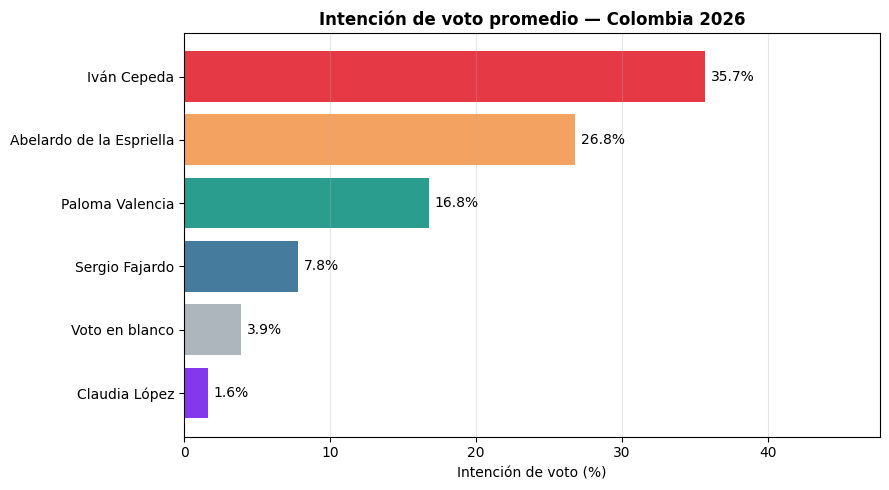

Guardado: grafico_promedio.png


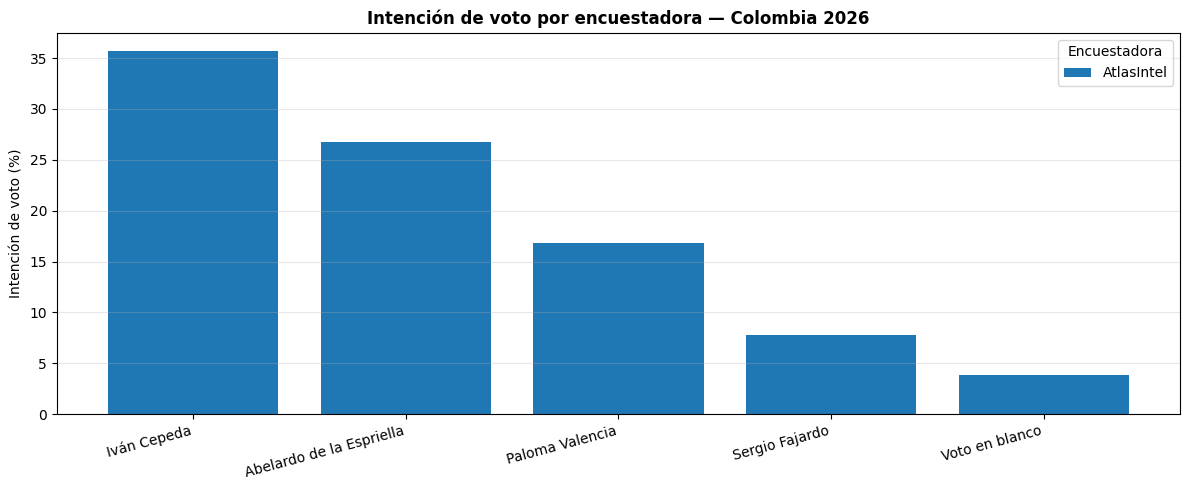

Guardado: grafico_encuestadoras.png


/tmp/ipykernel_43447/4092970975.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


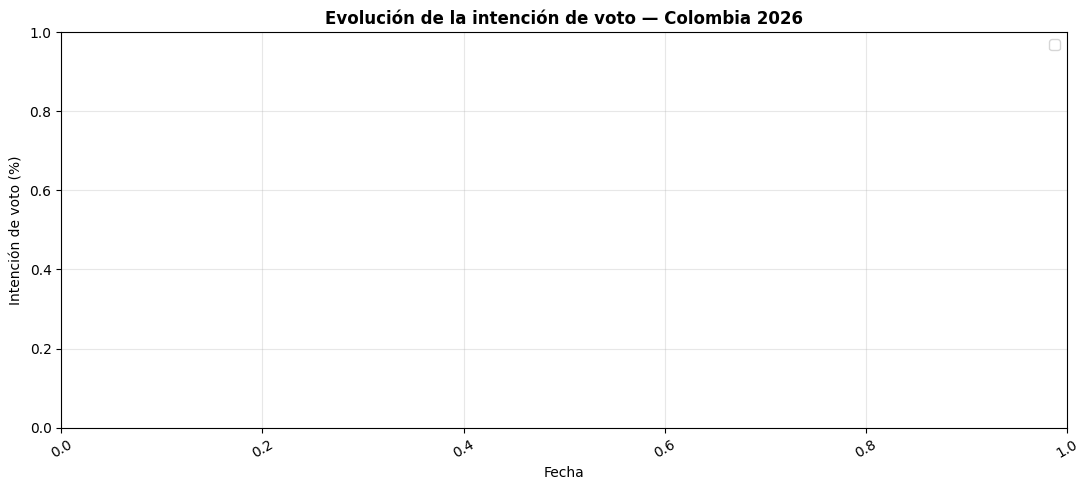

Guardado: grafico_tendencia.png


In [10]:
# =========================
# 9. VISUALIZACIONES (COMPLEMENTO)
# =========================
import matplotlib.pyplot as plt

# Colores fijos por candidato para que sean consistentes en todas las gráficas
COLORES = {
    "Iván Cepeda":              "#e63946",
    "Abelardo de la Espriella": "#f4a261",
    "Paloma Valencia":          "#2a9d8f",
    "Sergio Fajardo":           "#457b9d",
    "Claudia López":            "#8338ec",
    "Vicky Dávila":             "#fb8500",
    "Voto en blanco":           "#adb5bd",
}

# --- Gráfico 1: Promedio general (barras horizontales) ---
promedios = df.groupby("candidate")["vote"].mean().sort_values()
colores_barras = [COLORES.get(c, "#888888") for c in promedios.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(promedios.index, promedios.values, color=colores_barras)
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set_title("Intención de voto promedio — Colombia 2026", fontweight="bold")
ax.set_xlabel("Intención de voto (%)")
ax.set_xlim(0, promedios.max() + 12)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("grafico_promedio.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: grafico_promedio.png")

# --- Gráfico 2: Comparación por encuestadora (barras agrupadas) ---
fuentes = df["source"].unique()
candidatos_top = df.groupby("candidate")["vote"].mean().sort_values(ascending=False).head(5).index.tolist()
x = np.arange(len(candidatos_top))
ancho = 0.8 / len(fuentes)

fig, ax = plt.subplots(figsize=(12, 5))
for i, fuente in enumerate(fuentes):
    df_f = df[df["source"] == fuente]
    valores = [df_f[df_f["candidate"] == c]["vote"].mean() for c in candidatos_top]
    valores = [v if not np.isnan(v) else 0 for v in valores]
    offset = (i - len(fuentes) / 2) * ancho + ancho / 2
    ax.bar(x + offset, valores, width=ancho, label=fuente)

ax.set_xticks(x)
ax.set_xticklabels(candidatos_top, rotation=15, ha="right")
ax.set_title("Intención de voto por encuestadora — Colombia 2026", fontweight="bold")
ax.set_ylabel("Intención de voto (%)")
ax.legend(title="Encuestadora")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("grafico_encuestadoras.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: grafico_encuestadoras.png")

# --- Gráfico 3: Evolución temporal ---
fig, ax = plt.subplots(figsize=(11, 5))
for cand in candidatos_top:
    df_c = df[df["candidate"] == cand].sort_values("date")
    if len(df_c) >= 2:  # solo si hay al menos 2 puntos para trazar una línea
        ax.plot(df_c["date"], df_c["vote"],
                marker="o", linewidth=2,
                color=COLORES.get(cand, "gray"),
                label=cand)

ax.set_title("Evolución de la intención de voto — Colombia 2026", fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Intención de voto (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("grafico_tendencia.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: grafico_tendencia.png")